# Topic Modelling & Analysis

In [1]:
import json
import random
import statistics
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from gensim.corpora import Dictionary
from gensim.models import CoherenceModel
from gensim.models.phrases import Phrases, Phraser
from wordcloud import WordCloud
from transformers import pipeline
import warnings
from pathlib import Path
warnings.filterwarnings("ignore")

from sklearn.feature_extraction.text import (
    CountVectorizer,
    TfidfVectorizer,
    ENGLISH_STOP_WORDS
)

from sklearn.decomposition import (
    LatentDirichletAllocation,
    NMF
)

[transformers] Disabling PyTorch because PyTorch >= 2.4 is required but found 2.2.2
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [31]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
DATA_PATH = DATA_DIR / "video_data_processed.json"
TOPICS_PROCESSED_VIDEO_DATA_PATH = DATA_DIR / "video_data_topics_processed.json"

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

TOPIC_COUNTS = [2, 3, 4, 5, 8, 10]

TOP_WORDS = 10
TOP_MODELS_TO_INSPECT = 3
EXAMPLES_PER_TOPIC = 5

MIN_DF = 5
MAX_DF = 0.8

MAX_FEATURES = 10000

In [3]:
with open(DATA_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

processed_comments = data["comments"]

print(f"Loaded {len(processed_comments)} processed comments\n")

Loaded 46808 processed comments



In [4]:
for i, row in enumerate(processed_comments[:5]):

    print("=" * 110)
    print(f"COMMENT {i+1}")

    print("\nORIGINAL:")
    print(row["comment_text"])

    print("\nTOPIC TEXT:")
    print(row["comment_text_topic"])

    print("\nTOKENS:")
    print(row["comment_tokens_topic"])

COMMENT 1

ORIGINAL:
The whole thing is so phoney STIFF UNNATURAL SMILES..some.unimaginative outfits...so pretenscious all this money spent could have fed the world!..

TOPIC TEXT:
whole thing phoney stiff unnatural smiles unimaginative outfits pretenscious money spent could fed world

TOKENS:
['whole', 'thing', 'phoney', 'stiff', 'unnatural', 'smiles', 'unimaginative', 'outfits', 'pretenscious', 'money', 'spent', 'could', 'fed', 'world']
COMMENT 2

ORIGINAL:
Free the CHILDREN

TOPIC TEXT:
free children

TOKENS:
['free', 'children']
COMMENT 3

ORIGINAL:
Thank you so much 🎉🎉🎉🎉🎉🎉🎉🎉🎉❤❤❤❤❤❤

TOPIC TEXT:
thank much

TOKENS:
['thank', 'much']
COMMENT 4

ORIGINAL:
Thanks, it's an extraordinary event with so many amazing gowns. ❤❤❤

TOPIC TEXT:
thanks extraordinary event many amazing gowns

TOKENS:
['thanks', 'extraordinary', 'event', 'many', 'amazing', 'gowns']
COMMENT 5

ORIGINAL:
Why that song?

TOPIC TEXT:
song

TOKENS:
['song']


### Helpers

In [5]:
# token preparation
tokenised_docs = [
    row["comment_tokens_topic"]
    for row in processed_comments
]

original_comments = [
    row["comment_text"]
    for row in processed_comments
]

In [6]:
# bigram detection
phrases_model = Phrases(
    tokenised_docs,
    min_count=5,
    threshold=10
)

bigram_model = Phraser(phrases_model)

documents_with_phrases = [
    bigram_model[doc]
    for doc in tokenised_docs
]

In [7]:
for i in range(5):

    print("=" * 100)
    print(f"DOCUMENT {i+1}")

    print("\nWITHOUT PHRASES:")
    print(tokenised_docs[i])

    print("\nWITH PHRASES:")
    print(documents_with_phrases[i])

DOCUMENT 1

WITHOUT PHRASES:
['whole', 'thing', 'phoney', 'stiff', 'unnatural', 'smiles', 'unimaginative', 'outfits', 'pretenscious', 'money', 'spent', 'could', 'fed', 'world']

WITH PHRASES:
['whole_thing', 'phoney', 'stiff', 'unnatural', 'smiles', 'unimaginative', 'outfits', 'pretenscious', 'money_spent', 'could', 'fed', 'world']
DOCUMENT 2

WITHOUT PHRASES:
['free', 'children']

WITH PHRASES:
['free', 'children']
DOCUMENT 3

WITHOUT PHRASES:
['thank', 'much']

WITH PHRASES:
['thank_much']
DOCUMENT 4

WITHOUT PHRASES:
['thanks', 'extraordinary', 'event', 'many', 'amazing', 'gowns']

WITH PHRASES:
['thanks', 'extraordinary', 'event', 'many', 'amazing', 'gowns']
DOCUMENT 5

WITHOUT PHRASES:
['song']

WITH PHRASES:
['song']


In [8]:
# converting tokens to text
documents_text = [
    " ".join(doc)
    for doc in documents_with_phrases
]

In [9]:
# custom stopwords
custom_stopwords = set(ENGLISH_STOP_WORDS).union({

    # conversational filler
    "like", "look", "looks", "looking",
    "really", "think", "know",
    "people", "dont", "didnt",
    "say", "said", "make", "made",
    "going", "got", "get",

    # generic praise
    "good", "best", "beautiful",
    "amazing", "great", "love",
    "pretty", "nice",

    # platform noise
    "video", "watch",

    # generic dataset noise
    "year", "years", "time",
    "thing", "stuff", "way",
    "actually", "lot",

    # met gala specific generic terms
    "met", "gala", "met_gala",

    # emojis / internet style
    "lol", "omg", "haha"
})

## LDA

In [10]:
# count vectoriser for LDA
lda_vectorizer = CountVectorizer(
    stop_words=list(custom_stopwords),
    min_df=MIN_DF,
    max_df=MAX_DF,
    max_features=MAX_FEATURES
)

lda_dtm = lda_vectorizer.fit_transform(documents_text)

lda_feature_names = lda_vectorizer.get_feature_names_out()

print("LDA DTM Shape:", lda_dtm.shape)

LDA DTM Shape: (46808, 8327)


In [11]:
tokenised_for_coherence = [
    doc.split()
    for doc in documents_text
]

dictionary = Dictionary(tokenised_for_coherence)

In [27]:
# helper functions

def get_topics(model, feature_names, top_n=10):

    topics = []

    for topic in model.components_:

        top_indices = topic.argsort()[-top_n:][::-1]

        words = [
            feature_names[i]
            for i in top_indices
        ]

        topics.append(words)

    return topics


def compute_coherence(topics, texts, dictionary):

    coherence_model = CoherenceModel(
        topics=topics,
        texts=texts,
        dictionary=dictionary,
        coherence="c_v"
    )

    return coherence_model.get_coherence()


def get_topic_examples(model,
                       dtm,
                       original_comments,
                       n_topics,
                       n_examples=5):

    doc_topic = model.transform(dtm)
    
    results = {}

    for t in range(n_topics):

        # docs where this topic is at least somewhat present
        indices = doc_topic[:, t].argsort()[::-1][:50]

        # fallback if topic is sparse
        if len(indices) == 0:
            indices = np.arange(len(original_comments))

        sampled = random.sample(
            list(indices),
            min(n_examples, len(indices))
        )

        results[t] = [
            original_comments[i]
            for i in sampled
        ]

    return results

### Coherence Score Analysis

In [13]:
# training LDA models

lda_results = []
lda_saved_models = {}

for k in TOPIC_COUNTS:

    print("\n" + "=" * 80)
    print(f"TRAINING LDA ({k} TOPICS)")
    print("=" * 80)

    lda_model = LatentDirichletAllocation(
        n_components=k,
        learning_method="batch",
        random_state=RANDOM_STATE,
        max_iter=20
    )

    lda_model.fit(lda_dtm)

    topics = get_topics(
        lda_model,
        lda_feature_names,
        TOP_WORDS
    )

    coherence = compute_coherence(
        topics,
        tokenised_for_coherence,
        dictionary
    )

    print(f"\nCoherence Score: {coherence:.4f}")

    for i, topic in enumerate(topics):

        print(f"\nTOPIC {i}")
        print("-" * 60)
        print(", ".join(topic))

    lda_results.append({
        "num_topics": k,
        "coherence": coherence
    })

    lda_saved_models[k] = {
        "model": lda_model,
        "topics": topics
    }


TRAINING LDA (2 TOPICS)

Coherence Score: 0.5493

TOPIC 0
------------------------------------------------------------
dress, theme, art, fashion, outfit, jisoo, lisa, outfits, boring, wear

TOPIC 1
------------------------------------------------------------
beyonce, looks_like, need, world, shes, rihanna, girl, money, giving, right

TRAINING LDA (3 TOPICS)

Coherence Score: 0.5760

TOPIC 0
------------------------------------------------------------
theme, art, fashion, outfit, outfits, boring, wear, event, fashion_art, literally

TOPIC 1
------------------------------------------------------------
beyonce, shes, rihanna, world, need, right, real, looks_like, review, oh

TOPIC 2
------------------------------------------------------------
dress, jisoo, lisa, looked, looks_like, loved, thought, blackpink, rose, emma

TRAINING LDA (4 TOPICS)

Coherence Score: 0.5936

TOPIC 0
------------------------------------------------------------
theme, art, fashion, outfit, boring, outfits, wear

In [16]:
# LDA coherence results

lda_results_df = pd.DataFrame(lda_results)

lda_results_df = lda_results_df.sort_values(
    by="coherence",
    ascending=False
)

print("\n" + "=" * 80)
print("LDA COHERENCE RESULTS")
print("=" * 80)

print(lda_results_df.to_string(index=False))


LDA COHERENCE RESULTS
 num_topics  coherence
          4   0.593610
          3   0.576004
          2   0.549267
          5   0.522410
         10   0.499649
          8   0.457995


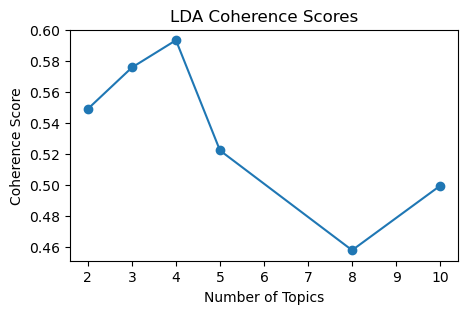

In [20]:
# ======================================================================================
# LDA COHERENCE PLOT
# ======================================================================================

plt.figure(figsize=(5, 3))

lda_results_df2 = pd.DataFrame(lda_results)

plt.plot(
    lda_results_df2["num_topics"],
    lda_results_df2["coherence"],
    marker="o"
)

plt.xlabel("Number of Topics")
plt.ylabel("Coherence Score")
plt.title("LDA Coherence Scores")

plt.show()

### Detailed LDA Analysis through Examples

In [21]:
# best LDA models

best_lda_models = lda_results_df["num_topics"] \
    .head(TOP_MODELS_TO_INSPECT) \
    .tolist()

print("Best LDA Topic Counts:", best_lda_models)

Best LDA Topic Counts: [4, 3, 2]


In [32]:
for k in best_lda_models:

    print("\n" + "#" * 100)
    print(f"DETAILED ANALYSIS: {k} TOPICS")
    print("#" * 100)

    model = lda_saved_models[k]["model"]
    topics = lda_saved_models[k]["topics"]

    print("\nTOPIC KEYWORDS")
    print("=" * 100)

    for i, topic in enumerate(topics):
        print("\n" + "-" * 60)
        print(f"TOPIC {i}")
        print("-" * 60)
        print(", ".join(topic))

    print("\nTOP EXAMPLES")
    print("=" * 100)

    examples = get_topic_examples(
        model,
        lda_dtm,
        original_comments,
        n_topics=k,
        n_examples=5
    )

    for topic_id, exs in examples.items():

        print("\n" + "-" * 60)
        print(f"TOPIC {topic_id}")
        print("-" * 60)

        for i, text in enumerate(exs, 1):
            print(f"\n{i}. {text}")


####################################################################################################
DETAILED ANALYSIS: 4 TOPICS
####################################################################################################

TOPIC KEYWORDS

------------------------------------------------------------
TOPIC 0
------------------------------------------------------------
theme, art, fashion, outfit, boring, outfits, wear, dress, fashion_art, event

------------------------------------------------------------
TOPIC 1
------------------------------------------------------------
beyonce, shes, need, world, money, real, ridiculous, want, right, women

------------------------------------------------------------
TOPIC 2
------------------------------------------------------------
dress, jisoo, lisa, blackpink, emma, stunning, rose, emma_chamberlain, ate, jennie

------------------------------------------------------------
TOPIC 3
---------------------------------------------------------


------------------------------------------------------------
TOPIC 0
------------------------------------------------------------

1. ​@hansikaroy3731 Supremist or supremacist isn't the point here. The thing is that scarves have been worn by everyone around the world. This so called "dupatta" of yours was worn in the EXACT same way by the Chinese too. So was that dupatta too? No. 

Scarves have different names in different cultures. Which doesn't mean that every scarf is a dupatta. You calling it dupatta is super disrespectful to the Chinese and also to some middle eastern cultures. 

Wrapping a scarf around yourself isn't something extraordinary. Everyone came up with it independently. 

So please grow out of it. This trend of calling every scarf a "dupatta" is super cringe and ignorant.

2. Every year your commentary helps me see and understand the outfits better . I tend to disregard the dresses on celebrities I don’t particularly care for, and you are fair-minded as well as very a

---------
From the LDA topic outputs and example comments, we observe a degree of topic blending, with multiple topics sharing high-frequency conversational terms and overlapping themes (e.g., fashion, outfits, celebrities). Although coherence scores are moderate, the qualitative inspection suggests limited topic separation. Therefore, we explore NMF (Non-negative Matrix Factorization) as a complementary method to obtain more distinct and interpretable topic structures.